<a href="https://colab.research.google.com/github/HersiZa/AES-Encryption-in-RDMA-Systems/blob/Main/Supplemental_Material_Plot_data_DEBS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

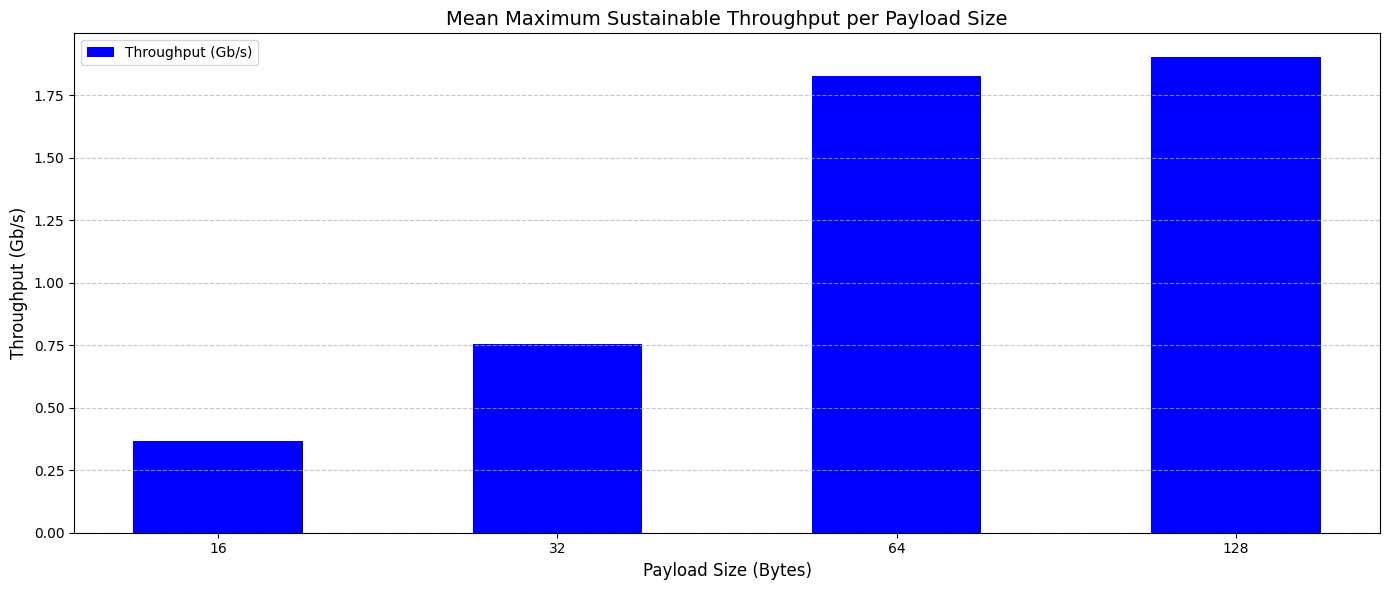

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data for the plot
payload_sizes = [16, 32, 64, 128]
avg_throughputs = [0.3684, 0.756, 1.8296, 1.9034]  # in Gb/s

# Create the plot
fig, ax = plt.subplots(figsize=(14, 6))  # Adjust the figure size to make it more rectangular

# Calculate the bar width
bar_width = 1

# Generate evenly spaced x positions for the bars with smaller spaces between them
x_pos = np.arange(len(payload_sizes)) * (bar_width * 2)

# Plot the throughput as a bar plot with thicker bars
ax.bar(x_pos, avg_throughputs, width=bar_width, color='blue', label='Throughput (Gb/s)')

# Set labels and title
ax.set_xlabel('Payload Size (Bytes)', fontsize=12)
ax.set_ylabel('Throughput (Gb/s)', fontsize=12)
ax.set_title('Mean Maximum Sustainable Throughput per Payload Size', fontsize=14)

# Set x-axis ticks and labels with even spacing
ax.set_xticks(x_pos)
ax.set_xticklabels(payload_sizes, fontsize=10)
ax.tick_params(axis='y', labelsize=10)

# Add grid for better readability
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add legend
ax.legend(loc='upper left', fontsize=10)

# Save the plot as a PDF file
plt.savefig('meanMaximumSustainableThroughput.pdf', bbox_inches='tight')

# Show the plot
plt.tight_layout()
plt.show()

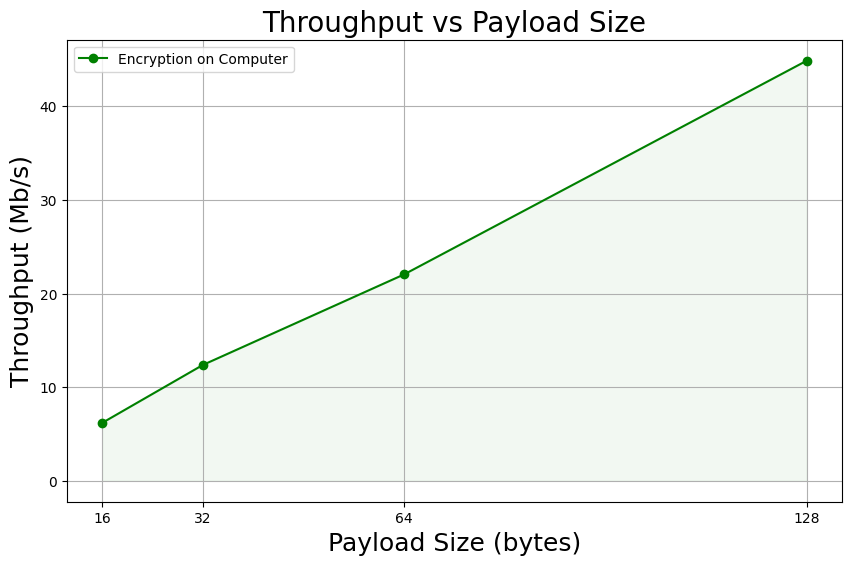

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data for the plots
payload_sizes = [16, 32, 64, 128]
throughput_c1 = [6.176, 12.366, 22.0444, 44.8779]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(payload_sizes, throughput_c1, color='green', marker='o', label='Encryption on Computer')
plt.fill_between(payload_sizes, throughput_c1, color='green', alpha=0.05)

# Add titles and labels
plt.title('Throughput vs Payload Size', fontsize=20)
plt.xlabel('Payload Size (bytes)', fontsize=18)
plt.ylabel('Throughput (Mb/s)', fontsize=18)
plt.legend()

# Set x-ticks to payload sizes
plt.xticks(payload_sizes)

# Show grid
plt.grid(True)

# Save the plot as a PDF
plt.savefig("Throughput_vs_Payload_Size_Baseline2.pdf", format='pdf')

# Display the plot
plt.show()


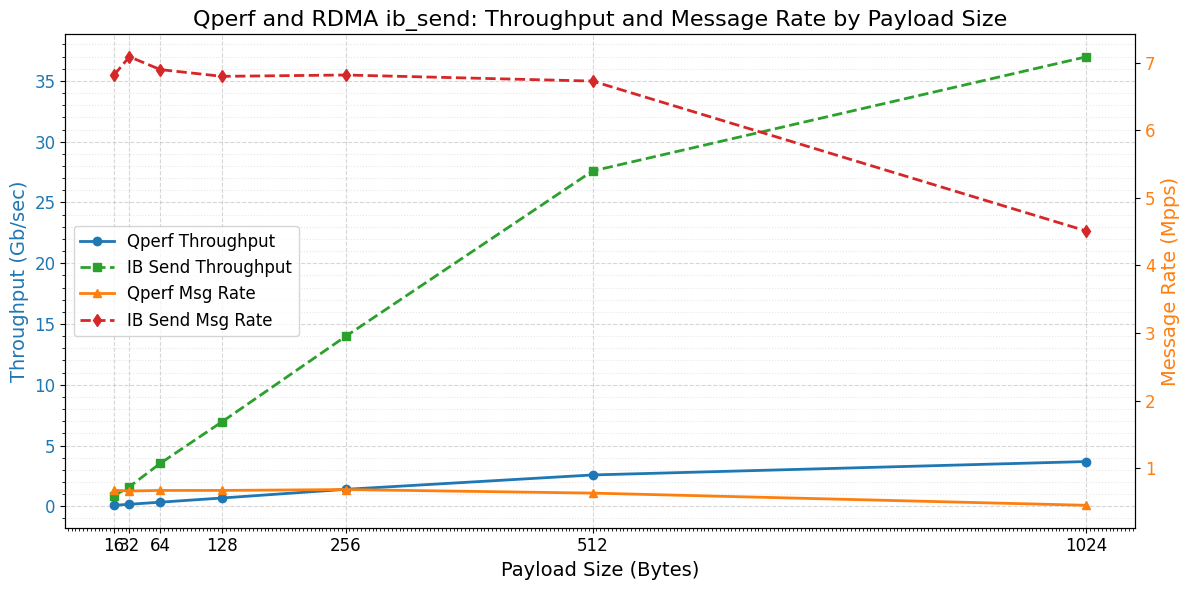

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#Merge of qperf and ib_send

# Data for the qperf tests
payload_sizes = [16, 32, 64, 128, 256, 512, 1024]
throughput_qperf = [0.086, 0.1694, 0.3430, 0.6861, 1.3988, 2.5821, 3.6864]
#throughput_qperf = [0.0861, 0.17, 0.343, 0.687, 1.36, 2.68, 5.23]  # OLD in Gb/sec
message_rates_qperf = [0.6717, 0.6617, 0.6700,  0.6700,  0.6830,  0.6304,  0.4500]  # in million messages per second (Mpps)
throughputIB = [0.87, 1.62, 3.54, 6.96, 13.98, 27.59, 36.99]  # in Gb/sec
message_ratesIB = [6.82, 7.09, 6.90, 6.8, 6.82, 6.73, 4.51]  # in million messages per second (Mpps)


x = np.array(payload_sizes)

# Create figure and twin axes
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# Plot lines
line1, = ax1.plot(x, throughput_qperf, marker='o', linestyle='-', linewidth=2, color='tab:blue', label='Qperf Throughput')
line2, = ax1.plot(x, throughputIB, marker='s', linestyle='--', linewidth=2, color='tab:green', label='IB Send Throughput')
line3, = ax2.plot(x, message_rates_qperf, marker='^', linestyle='-', linewidth=2, color='tab:orange', label='Qperf Msg Rate')
line4, = ax2.plot(x, message_ratesIB, marker='d', linestyle='--', linewidth=2, color='tab:red', label='IB Send Msg Rate')

# Axis labels and title
ax1.set_xlabel('Payload Size (Bytes)', fontsize=14)
ax1.set_ylabel('Throughput (Gb/sec)', fontsize=14, color='tab:blue')
ax2.set_ylabel('Message Rate (Mpps)', fontsize=14, color='tab:orange')
plt.title('Qperf and RDMA ib_send: Throughput and Message Rate by Payload Size', fontsize=16)

# Grid and ticks
ax1.set_xticks(x)
ax1.set_xticklabels(payload_sizes, fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:blue', labelsize=12)
ax2.tick_params(axis='y', labelcolor='tab:orange', labelsize=12)

# Major and minor grid lines
ax1.grid(True, which='major', axis='both', linestyle='--', alpha=0.5)
ax1.minorticks_on()
ax1.grid(True, which='minor', axis='y', linestyle=':', alpha=0.3)

# Add legend combining both axes
lines = [line1, line2, line3, line4]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='center left', fontsize=12)

# Optional: use log scale if needed (comment/uncomment as desired)
# ax1.set_yscale('log')
# ax2.set_yscale('log')

# Layout and save
plt.tight_layout()
plt.savefig("qperfvsibsendplot.pdf", format='pdf')
plt.show()



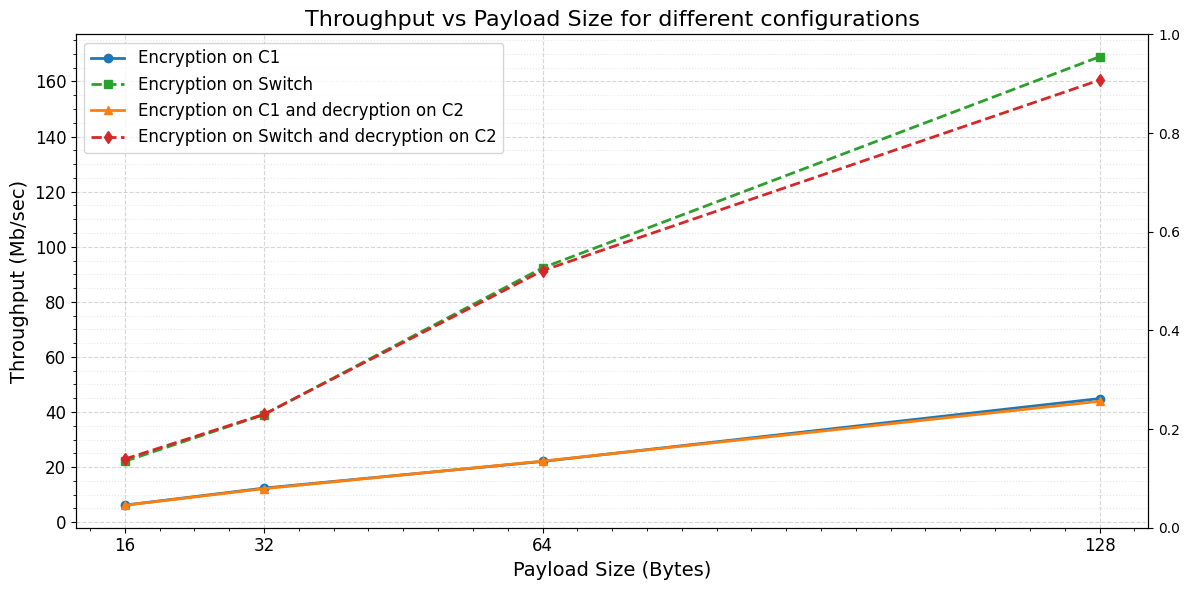

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#Plot of tables for encryption on c1 and switch and encryption on switch/c1 + decvryption on c2

# Data for the qperf tests
payload_sizes = [16, 32, 64, 128]
#Throughput for Encryption on C1
throughput_c1 = [6.17, 12.36, 22.04, 44.87]
#Throughput for Encryption on Switch
throughput_switch =  [22.08, 39.06, 92.33, 168.98]
#Throughput for Encryption on C1 and decryption on C2
throughput_Ec1_Dc2 =  [6.12, 12.16, 22.16, 43.88]
#Throughput for Encryption on Switch and decryption on C2
throughput_ES_D2 = [22.90, 39.16, 91.31, 160.51]

x = np.array(payload_sizes)

# Create figure and twin axes
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# Plot lines
line1, = ax1.plot(x, throughput_c1, marker='o', linestyle='-', linewidth=2, color='tab:blue', label='Encryption on C1')
line2, = ax1.plot(x, throughput_switch, marker='s', linestyle='--', linewidth=2, color='tab:green', label='Encryption on Switch')
line3, = ax1.plot(x, throughput_Ec1_Dc2, marker='^', linestyle='-', linewidth=2, color='tab:orange', label='Encryption on C1 and decryption on C2')
line4, = ax1.plot(x, throughput_ES_D2, marker='d', linestyle='--', linewidth=2, color='tab:red', label='Encryption on Switch and decryption on C2')

# Axis labels and title
ax1.set_xlabel('Payload Size (Bytes)', fontsize=14)
ax1.set_ylabel('Throughput (Mb/sec)', fontsize=14)
plt.title('Throughput vs Payload Size for different configurations', fontsize=16)

# Grid and ticks
ax1.set_xticks(x)
ax1.set_xticklabels(payload_sizes, fontsize=12)
ax1.tick_params(axis='y', labelsize=12)


# Major and minor grid lines
ax1.grid(True, which='major', axis='both', linestyle='--', alpha=0.5)
ax1.minorticks_on()
ax1.grid(True, which='minor', axis='y', linestyle=':', alpha=0.3)

# Add legend combining both axes
lines = [line1, line2, line3, line4]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=12)

# Optional: use log scale if needed (comment/uncomment as desired)
# ax1.set_yscale('log')
# ax2.set_yscale('log')

# Layout and save
plt.tight_layout()
plt.savefig("throughputconfigurations.pdf", format='pdf')
plt.show()
